horse: ['horse01-0.png', 'horse01-1.png', 'horse01-2.png', 'horse01-3.png', 'horse01-4.png', 'horse01-5.png', 'horse01-6.png', 'horse01-7.png', 'horse01-8.png', 'horse01-9.png', 'horse02-0.png', 'horse02-1.png', 'horse02-2.png', 'horse02-3.png', 'horse02-4.png', 'horse02-5.png', 'horse02-6.png', 'horse02-7.png', 'horse02-8.png', 'horse02-9.png', 'horse03-0.png', 'horse03-1.png', 'horse03-2.png', 'horse03-3.png', 'horse03-4.png', 'horse03-5.png', 'horse03-6.png', 'horse03-7.png', 'horse03-8.png', 'horse03-9.png', 'horse04-0.png', 'horse04-1.png', 'horse04-2.png', 'horse04-3.png', 'horse04-4.png', 'horse04-5.png', 'horse04-6.png', 'horse04-7.png', 'horse04-8.png', 'horse04-9.png', 'horse05-0.png', 'horse05-1.png', 'horse05-2.png', 'horse05-3.png', 'horse05-4.png', 'horse05-5.png', 'horse05-6.png', 'horse05-7.png', 'horse05-8.png', 'horse05-9.png', 'horse06-0.png', 'horse06-1.png', 'horse06-2.png', 'horse06-3.png', 'horse06-4.png', 'horse06-5.png', 'horse06-6.png', 'horse06-7.png', 'horse

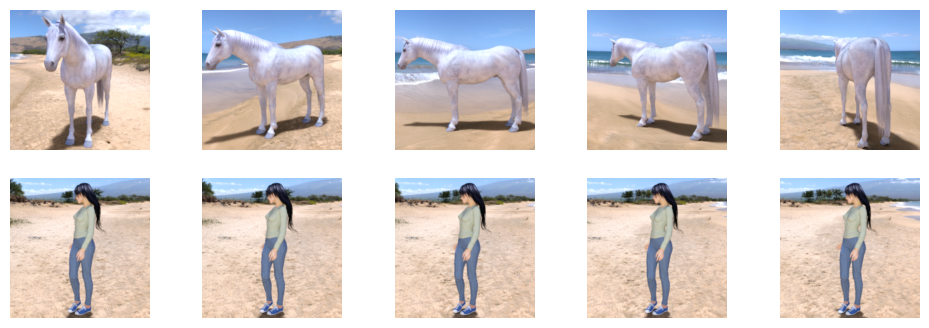

In [ ]:
# ======================================
# 필요한 라이브러리(도구)들 불러오기
# ======================================

import os  # 컴퓨터의 폴더와 파일 이름을 가져오기 위한 도구
import pandas as pd # 표 형태의 데이터 처리 (여기서는 아직 사용 안 함)
import cv2     # 이미지 처리(OpenCV)
import numpy as np # 숫자 계산용 (배열 처리)
import matplotlib.pyplot as plt # 그래프, 이미지 출력용
import matplotlib.image as maping # 이미지 파일 불러오기용
import tensorflow as tf # 딥러닝 라이브러리
from tensorflow.keras.optimizers import Adam # 학습 방법(옵티마이저)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# → 이미지 불러오고 늘려주는(증강) 도구

# ======================================
# 말(horse)과 사람(human) 이미지 폴더 경로
# ======================================

# 말 이미지들이 들어 있는 폴더 위치
train_horse_dir='./dataset/dataset/horse-or-human/train/horses'

# 사람 이미지들이 들어 있는 폴더 위치
train_human_dir='./dataset/dataset/horse-or-human/train/humans'


# ======================================
# 폴더 안에 있는 이미지 파일 이름 가져오기
# ======================================

# 말 이미지 파일 이름들을 리스트로 가져옴
# 예: ['horse01.png', 'horse02.png', ...]
train_horse_names=os.listdir(train_horse_dir)

# 사람 이미지 파일 이름들을 리스트로 가져옴
# 예: ['human01.png', 'human02.png', ...]
train_human_names=os.listdir(train_human_dir)


# ======================================
# 이미지의 전체 경로(주소) 만들기
# ======================================

# 말 이미지 파일들의 전체 경로 만들기
# 예: './dataset/.../horses/horse01.png'
horse_files=[train_horse_dir + '/' + f for f in train_horse_names]

# 사람 이미지 파일들의 전체 경로 만들기
# 예: './dataset/.../humans/human01.png'
human_files=[train_human_dir + '/' + f for f in train_human_names]


# ======================================
# 제대로 불러왔는지 확인 출력
# ======================================

# 말 이미지 파일 이름 목록 출력
print('horse:',train_horse_names)

# 사람 이미지 파일 이름 목록 출력
print("human:",train_human_names)

# ============================================
# 2행 5열짜리 그림판(액자 10개)을 만든다
# ============================================
fig,axes=plt.subplots(2,5,figsize=(12,4))


# fig   → 전체 도화지 (전체 창)
# axes  → 그림을 그릴 수 있는 "작은 칸들" (2x5 형태의 배열)


# axes는 이렇게 생김:
# [
#   [칸1, 칸2, 칸3, 칸4, 칸5],
#   [칸6, 칸7, 칸8, 칸9, 칸10]
# ]

# 이걸 한 줄짜리로 펴서
# [칸1, 칸2, 칸3, ..., 칸10] 형태로 바꾼다
ax=np.reshape(axes,-1)


# ============================================
# 말 이미지 5장 + 사람 이미지 5장을 화면에 출력
# ============================================

# horse_files[:5] → 말 이미지 5개
# human_files[:5] → 사람 이미지 5개
# 둘을 합쳐서 총 10개 이미지 사용
for i ,path in enumerate(horse_files[:5]+human_files[:5]):
     # path = 이미지 파일 하나의 위치(경로)
    # 예: "./dataset/.../horses/horse01.png"

    # 해당 경로에 있는 이미지를 실제로 읽어온다
    img=plt.imread(path)
    # i번째 칸(액자)을 선택해서
    # 좌표축(x,y 숫자)을 안 보이게 한다
    ax[i].axis('off')
    # i번째 칸(액자)에 이미지를 그린다
    ax[i].imshow(img)

# ============================================
# 모든 이미지를 화면에 표시
# ============================================
plt.show()

In [9]:
# =========================================================
# 말(horse) vs 사람(human)을 구분하는 CNN 모델 생성
# =========================================================

model = tf.keras.models.Sequential([

    # -----------------------------------------------------
    # 1️⃣ 첫 번째 합성곱층 (Conv2D)
    # -----------------------------------------------------
    tf.keras.layers.Conv2D(
        16,                 # 필터 개수 = 16개
                            # → 16개의 "눈"으로 사진을 봄
                            # → 가장 기본적인 선, 모서리, 윤곽을 찾음
        (3,3),              # 필터 크기 = 3x3
                            # → 작은 창으로 이미지를 훑으며 특징 추출
        activation='relu', # ReLU 함수
                            # → 중요한 특징만 살리고, 쓸모없는 음수값 제거
        input_shape=(300,300,3)  
                            # 입력 이미지 크기
                            # 300x300 픽셀, RGB 색상(3채널)
    ),

    # -----------------------------------------------------
    # 2️⃣ 첫 번째 Max Pooling (압축)
    # -----------------------------------------------------
    tf.keras.layers.MaxPool2D(
        2,2                # 2x2 영역에서 가장 큰 값만 남김
                            # → 이미지 크기를 반으로 줄임
                            # → 계산량 감소 + 중요한 특징 유지
    ),

    # -----------------------------------------------------
    # 3️⃣ 두 번째 합성곱층
    # -----------------------------------------------------
    tf.keras.layers.Conv2D(
        32,                # 필터 32개
                            # → 더 복잡한 패턴 감지 (눈, 코, 다리, 얼굴 등)
        (3,3),             # 3x3 크기로 특징 추출
        activation='relu'
    ),

    # -----------------------------------------------------
    # 4️⃣ 두 번째 Max Pooling
    # -----------------------------------------------------
    tf.keras.layers.MaxPool2D(2,2),

    # -----------------------------------------------------
    # 5️⃣ 세 번째 합성곱층
    # -----------------------------------------------------
    tf.keras.layers.Conv2D(
        64,                # 필터 64개
                            # → 아주 복잡한 형태 인식
                            # → 말 얼굴 vs 사람 얼굴 차이 학습
        (3,3),
        activation='relu'
    ),

    # -----------------------------------------------------
    # 6️⃣ 세 번째 Max Pooling
    # -----------------------------------------------------
    tf.keras.layers.MaxPool2D(2,2),

    # -----------------------------------------------------
    # 7️⃣ Flatten (펴기)
    # -----------------------------------------------------
    tf.keras.layers.Flatten(),
    # CNN이 추출한 특징맵을
    # 1줄짜리 숫자 벡터로 변환
    # → Dense(완전연결층)가 처리할 수 있도록 준비

    # -----------------------------------------------------
    # 8️⃣ 완전연결층(Dense)
    # -----------------------------------------------------
    tf.keras.layers.Dense(
        512,               # 뉴런 512개
                            # → 이미지 특징을 보고
                            #   말인지 사람인지 깊이 고민
        activation='relu'
    ),

    # -----------------------------------------------------
    # 9️⃣ 출력층
    # -----------------------------------------------------
    tf.keras.layers.Dense(
        1,                 # 출력 뉴런 1개
                            # → 이진 분류(말 vs 사람)
        activation='sigmoid'
                            # → 0~1 사이 확률로 출력
                            # 0에 가까우면 말
                            # 1에 가까우면 사람
    )
])

# -----------------------------------------------------
# 모델 구조 요약 출력
# -----------------------------------------------------
model.summary()


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 298, 298, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 149, 149, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 147, 147, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 78400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    40,141,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,165,409 (153.22 MB)

 Trainable params: 40,165,409 (153.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =====================================================
# 1️⃣ AI 모델에게 "어떻게 공부할지" 규칙을 알려줌
# =====================================================
model.compile(loss='binary_crossentropy',
              # loss(손실 함수)
                # → AI가 "얼마나 틀렸는지" 계산하는 공식
                # → 말 vs 사람 → 두 개 중 하나 맞추는 문제이므로
                #    binary_crossentropy 사용
              optimizer=Adam(learning_rate=0.001),
                  # optimizer(최적화 함수)
                # → AI가 틀린 답을 얼마나 어떻게 고칠지 정하는 방법
                # Adam = 가장 많이 쓰이는 똑똑한 학습 방법
                # learning_rate=0.001
                # → 한 번에 너무 많이 고치지 말고, 조금씩 안정적으로 고치라는 뜻
              metrics=['accuracy'])
                # accuracy = 맞춘 비율
                # → 학습하면서 "지금 몇 % 맞췄는지" 화면에 보여줌

In [ ]:
train_datagen=ImageDataGenerator(rescale=1/255)
# 이미지 픽셀값은 원래 0~255 범위
# AI는 0~1 범위의 숫자를 더 잘 학습함
# 그래서 모든 픽셀 값을 255로 나누어 정규화



# =====================================================
# 3️⃣ 학습용(Train) 이미지 불러오기
# =====================================================
train_generator=train_datagen.flow_from_directory(
    './dataset/dataset/horse-or-human/train',
     # 이 폴더 안에는
    # ├─ horses (말 사진들)
    # └─ humans (사람 사진들)
    # 이 구조로 들어 있음

    target_size=(300,300),
     # 모든 이미지를 300×300 크기로 맞춤
    # → CNN 모델의 입력 크기와 맞추기 위해

    batch_size=128,
    # 한 번에 AI에게 보여줄 이미지 개수
    # → 128장씩 묶어서 학습
    class_mode='binary'
     # 분류할 클래스가 2개
    # 말 vs 사람
    # → 말 = 0, 사람 = 1 로 자동 라벨 생성
)


# =====================================================
# 4️⃣ 검증용(Validation) 이미지 불러오기
# =====================================================

valid_generator=train_datagen.flow_from_directory(
    './dataset/dataset/horse-or-human/validation',
     # AI가 공부한 후 실력을 시험할 이미지 폴더
    target_size=(300,300),
    # 학습용과 같은 크기로 맞춤

    batch_size=128,
    # 한 번에 128장씩 불러옴
    class_mode='binary'
    # 역시 말 vs 사람 이진 분류
)

Found 1027 images belonging to 2 classes.
Found 256 images belonging to 2 classes.


In [ ]:
# =====================================================
# 1️⃣ AI 모델 학습 시작 (사진 보고 공부)
# =====================================================
history=model.fit(
    train_generator,# 말·사람 학습용 이미지들
    steps_per_epoch=8,  # 한 번의 epoch(한 바퀴 학습)에
                          # 8번의 배치(batch)를 사용
                          # batch_size=128 이므로
                          # → 한 epoch당 128×8 = 1024장의 사진을 봄
    epochs=15,            # 전체 학습을 15번 반복
                          # → 사진을 여러 번 보며 점점 정답에 가까워짐
    verbose=1            # 학습 과정을 화면에 출력
)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5938 - loss: 2.6608
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6667 - loss: 0.5687 
Epoch 3/15


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 617ms/step - accuracy: 0.9210 - loss: 0.2608
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 799us/step - accuracy: 0.9453 - loss: 0.1469
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9566 - loss: 0.1101
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9609 - loss: 0.0813
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 833ms/step - accuracy: 0.9733 - loss: 0.0658
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - accuracy: 0.9844 - loss: 0.0608
Epoch 9/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 613ms/step - accuracy: 0.9911 - loss: 0.0209
Epoch 10/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - accuracy: 1.0000 - loss: 0.0079
Epoch 11/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 605ms/step - accuracy: 0.9967 - loss: 0.0113
Epoch 12/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 889us/step - accuracy: 1.0000 - loss: 0.0134
Epoch 13/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 671ms/step - accuracy: 0.9990 - loss: 0.0086
Epoch 14/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0054 
Epoc

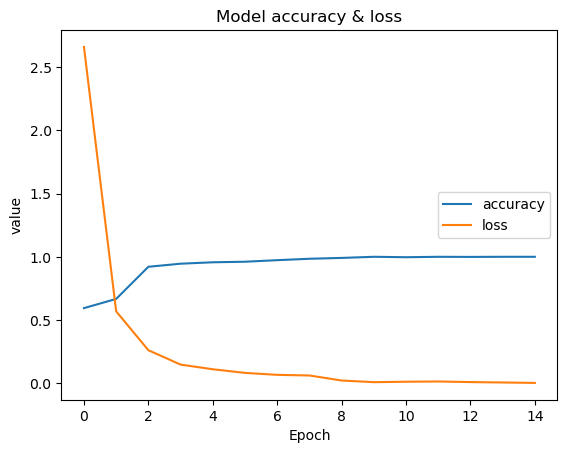

In [ ]:
# =====================================================
# 2️⃣ 학습 결과(기록)에서 정확도와 손실값 가져오기
# =====================================================

# 각 epoch마다의 정확도(accuracy) 기록
plt.plot(history.history['accuracy'])
# 각 epoch마다의 오차(loss) 기록
plt.plot(history.history['loss'])
plt.title('Model accuracy & loss') # 그래프 제목
plt.xlabel('Epoch')               # x축 → 학습 횟수
plt.ylabel('value')              # y축 → 값(정확도, 손실)

# 어떤 선이 무엇인지 설명
plt.legend(['accuracy','loss'], loc='center right')
# 그래프 화면에 출력
plt.show()

In [ ]:
# =====================================================
# 4️⃣ 검증 데이터로 AI 실력 테스트
# =====================================================

# 학습에 사용하지 않은 사진들로 시험
results=model.evaluate(valid_generator)

# 결과 출력
# results[0] → test loss (얼마나 틀렸는지)
# results[1] → test accuracy (얼마나 맞췄는지)
print("test loss, test acc:",results)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 318ms/step - accuracy: 0.8516 - loss: 1.5431
test loss, test acc: [1.5430574417114258, 0.8515625]


In [17]:
dlist = './dataset/dataset/horse-or-human/test/'
predict_list=os.listdir(dlist)

print(predict_list)

img=[cv2.imread(dlist+i) for i in predict_list]
img=[cv2.resize(i,(300,300)) for i in img]
img=np.array(img)
img=img.astype('float32')/255.0

cutoff=.5
predictions=model.predict(img)
print(predictions >= cutoff)

['horse1.jpg', 'horse2.webp', 'horse3.jpg', 'human1.jpg', 'human2.jpg']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
[[False]
 [False]
 [ True]
 [False]
 [ True]]
